# Task
Implement a Self-Organizing Map (SOM) from scratch in Python for unsupervised learning. This involves selecting and loading a publicly available dataset, initializing SOM weights, implementing the core SOM training logic (BMU finding, neighborhood function, learning rate decay, weight update), training the SOM, and visualizing the results through a U-matrix, feature maps, and data point mapping, finally summarizing the findings.

## Select and Load Dataset

### Subtask:
Choose a suitable publicly available dataset for unsupervised learning (e.g., Iris, Wine, or similar) and load it into a pandas DataFrame or NumPy array. Preprocess the data if necessary (e.g., normalization).


**Reasoning**:
I will import the necessary libraries, load the Iris dataset, extract its features, and then normalize the data using MinMaxScaler as per the instructions.



In [ ]:
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Load the Iris dataset
iris = datasets.load_iris()

# Extract the feature data
X = iris.data
y = iris.target # Also store target data, though not directly used in unsupervised learning

# Initialize a MinMaxScaler object
scaler = MinMaxScaler()

# Apply the scaler to the feature data to normalize it
X_scaled = scaler.fit_transform(X)

# Optionally, create a DataFrame from the scaled data for easier inspection
df_iris_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)

print("Original features (first 5 rows):\n", X[:5])
print("\nScaled features (first 5 rows):\n", df_iris_scaled.head())
print("\nShape of scaled data:", X_scaled.shape)

Original features (first 5 rows):
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

Scaled features (first 5 rows):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0           0.222222          0.625000           0.067797          0.041667
1           0.166667          0.416667           0.067797          0.041667
2           0.111111          0.500000           0.050847          0.041667
3           0.083333          0.458333           0.084746          0.041667
4           0.194444          0.666667           0.067797          0.041667

Shape of scaled data: (150, 4)


## Implement SOM Initialization

### Subtask:
Write a Python function to initialize the weights of the Self-Organizing Map (SOM) grid. The weights should be initialized randomly or with small values, considering the dimensions of the input data and the desired SOM grid size.


**Reasoning**:
The subtask requires implementing a Python function to initialize the SOM weights. I will define the function `initialize_weights` as per the instructions and then demonstrate its usage by calling it with appropriate parameters derived from the `X_scaled` data.



In [ ]:
import numpy as np

def initialize_weights(grid_rows, grid_cols, input_dim):
    """
    Initializes the weights of the SOM grid with random values between 0 and 1.

    Args:
        grid_rows (int): Number of rows in the SOM grid.
        grid_cols (int): Number of columns in the SOM grid.
        input_dim (int): Number of features in the input data.

    Returns:
        np.ndarray: A 3D NumPy array representing the initialized SOM weights.
    """
    # Initialize weights with random values uniformly distributed between 0 and 1
    # The shape will be (grid_rows, grid_cols, input_dim)
    weights = np.random.rand(grid_rows, grid_cols, input_dim)
    return weights

# Example usage:
# Assuming a 10x10 SOM grid and input_dim from the X_scaled data
grid_rows = 10
grid_cols = 10
input_dim = X_scaled.shape[1] # Number of features from the scaled Iris data

som_weights = initialize_weights(grid_rows, grid_cols, input_dim)

print(f"SOM grid dimensions: {grid_rows}x{grid_cols}")
print(f"Input data dimensions (features): {input_dim}")
print(f"Shape of initialized SOM weights: {som_weights.shape}")
print("First weight vector in the SOM grid (top-left neuron):")
print(som_weights[0, 0])

SOM grid dimensions: 10x10
Input data dimensions (features): 4
Shape of initialized SOM weights: (10, 10, 4)
First weight vector in the SOM grid (top-left neuron):
[0.85384692 0.37807309 0.57470904 0.32893116]


## Implement SOM Training Logic

### Subtask:
Develop the core SOM training algorithm by implementing functions for finding the Best Matching Unit (BMU), a Gaussian neighborhood function, and a decay function for learning rate and neighborhood radius.


**Reasoning**:
I will define the three required functions: `find_bmu` to determine the Best Matching Unit, `gaussian_neighborhood` to calculate the influence of a neuron based on its distance from the BMU, and `decay_function` for dynamic adjustment of learning rate and neighborhood radius during SOM training. These functions are essential components of the SOM training algorithm and directly address the subtask instructions.



In [ ]:
import numpy as np

def find_bmu(input_vector, som_weights):
    """
    Finds the Best Matching Unit (BMU) for a given input vector.

    Args:
        input_vector (np.ndarray): The input data point (1D array).
        som_weights (np.ndarray): The SOM weight vectors (3D array: rows, cols, input_dim).

    Returns:
        tuple: The (row, col) coordinates of the BMU.
    """
    # Calculate squared Euclidean distances between the input vector and all SOM weight vectors
    # Reshape weights to (num_neurons, input_dim) for easier broadcasting
    num_rows, num_cols, input_dim = som_weights.shape
    flattened_weights = som_weights.reshape(-1, input_dim)

    # Compute squared Euclidean distance for all neurons at once
    # (input_vector - flattened_weights) gives (num_neurons, input_dim)
    # np.sum(..., axis=1) sums up the squared differences for each neuron
    distances_sq = np.sum((input_vector - flattened_weights)**2, axis=1)

    # Find the index of the minimum distance
    bmu_flat_idx = np.argmin(distances_sq)

    # Convert the flat index back to 2D grid coordinates
    bmu_row, bmu_col = np.unravel_index(bmu_flat_idx, (num_rows, num_cols))

    return bmu_row, bmu_col

def gaussian_neighborhood(bmu_coords, neuron_coords, radius):
    """
    Calculates the Gaussian neighborhood influence for a given neuron.

    Args:
        bmu_coords (tuple): (row, col) coordinates of the BMU.
        neuron_coords (tuple): (row, col) coordinates of the neuron.
        radius (float): The current neighborhood radius.

    Returns:
        float: The influence value for the neuron.
    """
    # Calculate squared Euclidean distance between BMU and neuron coordinates in the grid
    distance_sq = np.sum((np.array(bmu_coords) - np.array(neuron_coords))**2)

    # Apply Gaussian function
    # Avoid division by zero if radius is very small
    if radius == 0:
        return 1.0 if distance_sq == 0 else 0.0
    return np.exp(-(distance_sq) / (2 * radius**2))

def decay_function(initial_value, current_iteration, total_iterations):
    """
    Implements an exponential decay for a given value.

    Args:
        initial_value (float): The starting value to decay.
        current_iteration (int): The current training iteration.
        total_iterations (int): The total number of training iterations.

    Returns:
        float: The decayed value.
    """
    # Ensure current_iteration is within bounds
    if current_iteration >= total_iterations:
        return initial_value * np.exp(-1.0)

    # Exponential decay formula
    # A small constant like 1.0 is used for the exponent numerator to scale the decay properly.
    # Using total_iterations in the denominator ensures that the decay happens over the full training period.
    return initial_value * np.exp(-current_iteration / float(total_iterations))

# --- Demonstration of functions ---
# Using the previously initialized som_weights (10x10x4)
# and scaled data X_scaled

# 1. Test find_bmu
print("\n--- Testing find_bmu ---")
# Take the first data point from X_scaled
sample_input = X_scaled[0]
bmu_coords = find_bmu(sample_input, som_weights)
print(f"Sample input vector (first 5 values): {sample_input[:5]}")
print(f"BMU for sample input: {bmu_coords}")

# 2. Test gaussian_neighborhood
print("\n--- Testing gaussian_neighborhood ---")
neuron_coords = (bmu_coords[0] + 1, bmu_coords[1]) # A neighbor neuron
current_radius = 5.0 # Example radius
influence = gaussian_neighborhood(bmu_coords, neuron_coords, current_radius)
print(f"BMU coordinates: {bmu_coords}")
print(f"Neighbor neuron coordinates: {neuron_coords}")
print(f"Current radius: {current_radius}")
print(f"Neighborhood influence on neighbor: {influence:.4f}")

neuron_coords_same = bmu_coords # Same neuron as BMU
influence_same = gaussian_neighborhood(bmu_coords, neuron_coords_same, current_radius)
print(f"Neighborhood influence on BMU itself: {influence_same:.4f}")

# 3. Test decay_function
print("\n--- Testing decay_function ---")
initial_learning_rate = 0.5
total_epochs = 100

# Decay at beginning
decayed_lr_start = decay_function(initial_learning_rate, 0, total_epochs)
print(f"Initial learning rate: {initial_learning_rate}")
print(f"Decayed learning rate at iteration 0: {decayed_lr_start:.4f}")

# Decay at middle
decayed_lr_mid = decay_function(initial_learning_rate, total_epochs // 2, total_epochs)
print(f"Decayed learning rate at iteration {total_epochs // 2}: {decayed_lr_mid:.4f}")

# Decay at end
decayed_lr_end = decay_function(initial_learning_rate, total_epochs - 1, total_epochs)
print(f"Decayed learning rate at iteration {total_epochs - 1}: {decayed_lr_end:.4f}")


--- Testing find_bmu ---
Sample input vector (first 5 values): [0.22222222 0.625      0.06779661 0.04166667]
BMU for sample input: (np.int64(9), np.int64(7))

--- Testing gaussian_neighborhood ---
BMU coordinates: (np.int64(9), np.int64(7))
Neighbor neuron coordinates: (np.int64(10), np.int64(7))
Current radius: 5.0
Neighborhood influence on neighbor: 0.9802
Neighborhood influence on BMU itself: 1.0000

--- Testing decay_function ---
Initial learning rate: 0.5
Decayed learning rate at iteration 0: 0.5000
Decayed learning rate at iteration 50: 0.3033
Decayed learning rate at iteration 99: 0.1858


## Train the SOM (Weight Update)

### Subtask:
Implement the weight update rule and integrate all core SOM functions into a complete training loop.


**Reasoning**:
I will implement the `train_som` function as described in the instructions, integrating the `find_bmu`, `gaussian_neighborhood`, and `decay_function` to create a complete SOM training loop. Then, I will call this function with the preprocessed data and initial parameters, and print the shape of the resulting trained weights to verify the training process.



In [ ]:
import numpy as np

def train_som(X_data, som_weights, grid_rows, grid_cols, initial_learning_rate, initial_radius, n_epochs):
    """
    Trains the Self-Organizing Map (SOM).

    Args:
        X_data (np.ndarray): The input data (scaled).
        som_weights (np.ndarray): The initialized SOM weight vectors.
        grid_rows (int): Number of rows in the SOM grid.
        grid_cols (int): Number of columns in the SOM grid.
        initial_learning_rate (float): The starting learning rate.
        initial_radius (float): The starting neighborhood radius.
        n_epochs (int): Total number of training iterations.

    Returns:
        np.ndarray: The trained SOM weights.
    """

    num_data_points = X_data.shape[0]

    for epoch in range(n_epochs):
        # Update learning rate and neighborhood radius using decay function
        current_learning_rate = decay_function(initial_learning_rate, epoch, n_epochs)
        # Scale radius relative to grid size for initial value
        current_radius = decay_function(initial_radius * max(grid_rows, grid_cols) / 2, epoch, n_epochs)

        # Randomly permute the data points for each epoch
        shuffled_indices = np.random.permutation(num_data_points)
        X_shuffled = X_data[shuffled_indices]

        for i, input_vector in enumerate(X_shuffled):
            # 1a. Find the Best Matching Unit (BMU)
            bmu_row, bmu_col = find_bmu(input_vector, som_weights)

            # 1b. Iterate through all neurons in the SOM grid
            for r in range(grid_rows):
                for c in range(grid_cols):
                    neuron_coords = (r, c)

                    # 1c. Calculate neighborhood influence
                    influence = gaussian_neighborhood((bmu_row, bmu_col), neuron_coords, current_radius)

                    # 1d. Update the neuron's weights
                    # som_weights[r, c] = som_weights[r, c] + current_learning_rate * influence * (input_vector - som_weights[r, c])
                    som_weights[r, c] += current_learning_rate * influence * (input_vector - som_weights[r, c])

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs} - Learning Rate: {current_learning_rate:.4f}, Radius: {current_radius:.4f}")

    return som_weights

# --- Call the train_som function and print results ---

# Define training parameters
n_epochs = 100
initial_learning_rate = 0.5
initial_radius = 1.0 # This will be scaled inside the function

# Re-initialize weights for a fresh training run demonstration
som_weights_initial = initialize_weights(grid_rows, grid_cols, input_dim)

print(f"\nStarting SOM training with {n_epochs} epochs...")
print(f"Initial learning rate: {initial_learning_rate}")
print(f"Initial radius (pre-scaled): {initial_radius}")

trained_som_weights = train_som(X_scaled, som_weights_initial, grid_rows, grid_cols, initial_learning_rate, initial_radius, n_epochs)

print(f"\nShape of trained SOM weights: {trained_som_weights.shape}")
print("First weight vector in the trained SOM grid (top-left neuron):")
print(trained_som_weights[0, 0])


Starting SOM training with 100 epochs...
Initial learning rate: 0.5
Initial radius (pre-scaled): 1.0
Epoch 10/100 - Learning Rate: 0.4570, Radius: 4.5697
Epoch 20/100 - Learning Rate: 0.4135, Radius: 4.1348
Epoch 30/100 - Learning Rate: 0.3741, Radius: 3.7413
Epoch 40/100 - Learning Rate: 0.3385, Radius: 3.3853
Epoch 50/100 - Learning Rate: 0.3063, Radius: 3.0631
Epoch 60/100 - Learning Rate: 0.2772, Radius: 2.7716
Epoch 70/100 - Learning Rate: 0.2508, Radius: 2.5079
Epoch 80/100 - Learning Rate: 0.2269, Radius: 2.2692
Epoch 90/100 - Learning Rate: 0.2053, Radius: 2.0533
Epoch 100/100 - Learning Rate: 0.1858, Radius: 1.8579

Shape of trained SOM weights: (10, 10, 4)
First weight vector in the trained SOM grid (top-left neuron):
[0.73905994 0.4783939  0.80323878 0.8121061 ]


## Visualize SOM Results

### Subtask:
Generate visualizations to interpret the trained SOM, including a U-matrix, feature maps, and data point mapping.


**Reasoning**:
I need to define a function to calculate the U-matrix, which involves computing the Euclidean distance between each neuron's weight vector and its immediate neighbors in the SOM grid. This directly addresses the first instruction of the subtask.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_umatrix(som_weights):
    """
    Calculates the U-matrix for a given SOM.

    The U-matrix visualizes the distances between neighboring neurons in the SOM grid.
    Higher values indicate larger distances, suggesting boundaries between clusters.

    Args:
        som_weights (np.ndarray): The trained SOM weight vectors (rows, cols, input_dim).

    Returns:
        np.ndarray: The U-matrix, with dimensions (2*rows - 1, 2*cols - 1),
                    where inter-neuron distances are interleaved with neuron positions.
    """
    grid_rows, grid_cols, input_dim = som_weights.shape

    # The U-matrix will have interleaved neuron positions and distances
    # Its size will be (2*rows - 1, 2*cols - 1)
    umatrix = np.zeros((grid_rows * 2 - 1, grid_cols * 2 - 1))

    # Helper function to compute Euclidean distance between two weight vectors
    def euclidean_distance(w1, w2):
        return np.linalg.norm(w1 - w2)

    for r in range(grid_rows):
        for c in range(grid_cols):
            # Place neuron's average distance at (2*r, 2*c) in umatrix
            # This is a placeholder for now, the actual average distance will be calculated later.
            # For now, we are placing the distances BETWEEN neurons.

            # Calculate distances to neighbors (horizontal and vertical)
            distances = []

            # Right neighbor
            if c < grid_cols - 1:
                dist_right = euclidean_distance(som_weights[r, c], som_weights[r, c + 1])
                umatrix[2*r, 2*c + 1] = dist_right
                distances.append(dist_right)

            # Down neighbor
            if r < grid_rows - 1:
                dist_down = euclidean_distance(som_weights[r, c], som_weights[r + 1, c])
                umatrix[2*r + 1, 2*c] = dist_down
                distances.append(dist_down)

            # Diagonal (down-right) - this is less common for simple U-matrix but can be included
            # For a standard U-matrix, we usually average the direct neighbors
            # If we want to strictly follow average of direct neighbors for the neuron position:

            # If there are distances, calculate average for the neuron's cell
            if distances:
                umatrix[2*r, 2*c] = np.mean(distances)
            else:
                # If a neuron has no neighbors (e.g., 1x1 grid), its value is 0 or its distance to itself
                # For now, set to 0. It should not happen in a grid larger than 1x1 anyway.
                umatrix[2*r, 2*c] = 0

    # Fill in the average distances for the 'empty' cells where no direct neighbor distance was placed
    # These are the cells corresponding to the neurons themselves (2*r, 2*c)
    # and the diagonal 'cross' sections (2*r+1, 2*c+1)
    # A common approach is to average its surrounding distances
    # Let's refine the averaging for neuron positions and diagonal connections.

    # Recalculate neuron cell values as the average of their direct connections
    for r in range(grid_rows):
        for c in range(grid_cols):
            sum_dist = 0
            count = 0
            # Direct right
            if c < grid_cols - 1:
                sum_dist += umatrix[2*r, 2*c + 1]
                count += 1
            # Direct down
            if r < grid_rows - 1:
                sum_dist += umatrix[2*r + 1, 2*c]
                count += 1
            # Direct left (from neighbor's perspective)
            if c > 0:
                sum_dist += umatrix[2*r, 2*c - 1]
                count += 1
            # Direct up (from neighbor's perspective)
            if r > 0:
                sum_dist += umatrix[2*r - 1, 2*c]
                count += 1

            if count > 0:
                umatrix[2*r, 2*c] = sum_dist / count

    # Fill diagonal cells by averaging their horizontal and vertical neighbors
    for r_um in range(1, grid_rows * 2 - 1, 2):
        for c_um in range(1, grid_cols * 2 - 1, 2):
            # Average its four surrounding distances
            neighbors_sum = 0
            neighbors_count = 0
            if c_um > 0: # Left
                neighbors_sum += umatrix[r_um, c_um - 1]
                neighbors_count += 1
            if c_um < umatrix.shape[1] - 1: # Right
                neighbors_sum += umatrix[r_um, c_um + 1]
                neighbors_count += 1
            if r_um > 0: # Up
                neighbors_sum += umatrix[r_um - 1, c_um]
                neighbors_count += 1
            if r_um < umatrix.shape[0] - 1: # Down
                neighbors_sum += umatrix[r_um + 1, c_um]
                neighbors_count += 1

            if neighbors_count > 0:
                umatrix[r_um, c_um] = neighbors_sum / neighbors_count

    return umatrix

# --- Test the U-matrix calculation ---
print("\n--- Testing U-matrix calculation ---")
umatrix_data = calculate_umatrix(trained_som_weights)
print(f"Shape of U-matrix: {umatrix_data.shape}")
print("First 5x5 section of U-matrix:\n", umatrix_data[:5, :5])



--- Testing U-matrix calculation ---
Shape of U-matrix: (19, 19)
First 5x5 section of U-matrix:
 [[0.04015676 0.04061425 0.03882308 0.03862716 0.04218697]
 [0.03969926 0.03871856 0.03722782 0.03967937 0.04162159]
 [0.04702329 0.03733292 0.04455219 0.04124091 0.05118347]
 [0.06403769 0.04972811 0.0624071  0.05438393 0.06769481]
 [0.06346719 0.03513472 0.05787562 0.04619291 0.06578122]]


**Reasoning**:
I will now visualize the calculated U-matrix using a heatmap, which is the second instruction of the subtask, to interpret the distances between neighboring neurons.



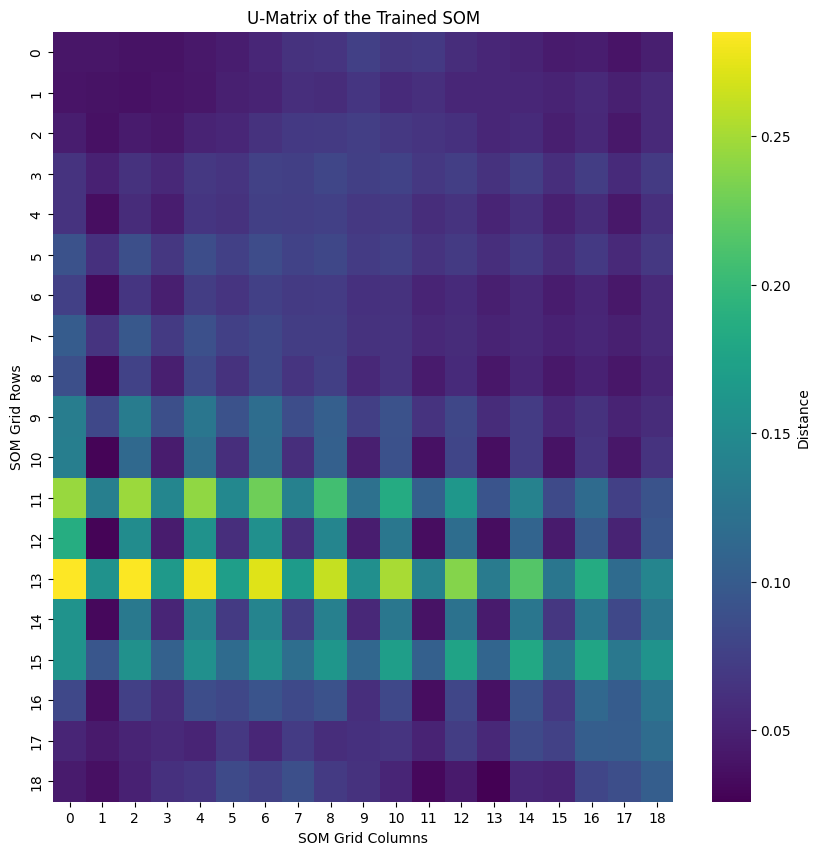

U-matrix visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Visualize the U-matrix using a heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(umatrix_data, cmap='viridis', annot=False, fmt=".2f", cbar_kws={'label': 'Distance'})
plt.title('U-Matrix of the Trained SOM')
plt.xlabel('SOM Grid Columns')
plt.ylabel('SOM Grid Rows')
plt.show()
print("U-matrix visualization complete.")

**Reasoning**:
I will now generate feature maps for each input dimension, which is the third instruction of the subtask. This involves plotting a heatmap for each feature, showing its weight distribution across the SOM grid, using subplots for clear visualization.



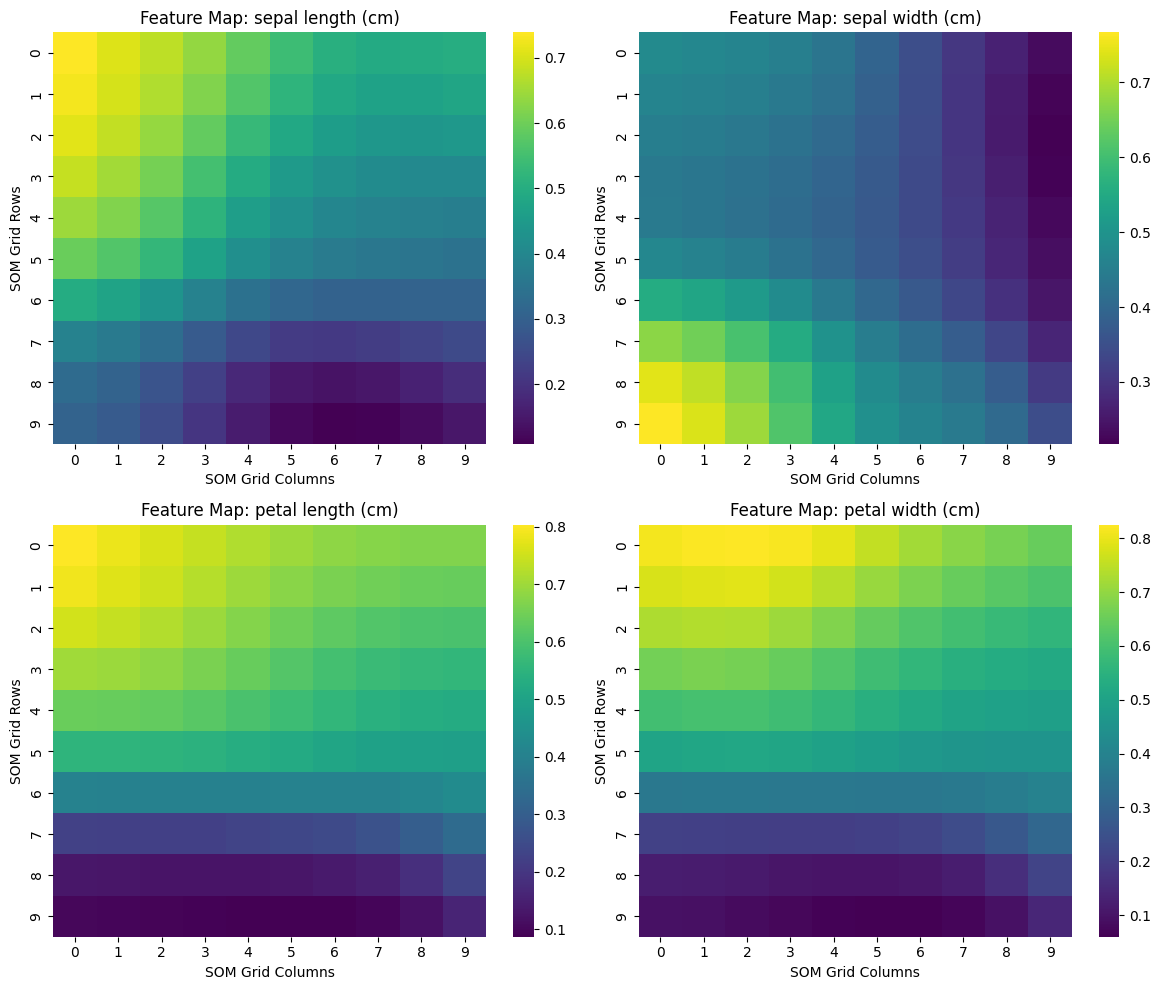

Feature maps visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Create feature maps for each input dimension

# Get the number of features (input dimensions)
num_features = trained_som_weights.shape[2]

# Get feature names from the original Iris dataset for better labels
feature_names = iris.feature_names

# Determine grid size for subplots. Use a 2x2 grid if 4 features, adjust for more/less.
subplot_rows = int(np.ceil(num_features / 2.0))
subplot_cols = 2 # Keeping it at 2 columns for better layout

plt.figure(figsize=(subplot_cols * 6, subplot_rows * 5))

for i in range(num_features):
    plt.subplot(subplot_rows, subplot_cols, i + 1)

    # Extract the weight map for the current feature
    feature_map = trained_som_weights[:, :, i]

    # Create a heatmap for the feature map
    sns.heatmap(feature_map, cmap='viridis', annot=False, cbar=True)

    # Set title and labels
    plt.title(f'Feature Map: {feature_names[i]}')
    plt.xlabel('SOM Grid Columns')
    plt.ylabel('SOM Grid Rows')

plt.tight_layout()
plt.show()
print("Feature maps visualization complete.")

**Reasoning**:
I will now map the original data points to their Best Matching Units (BMUs) on the trained SOM grid, which is the fourth instruction of the subtask. This involves iterating through each data point in `X_scaled` and using the `find_bmu` function to determine its BMU coordinates, storing these mappings for later visualization.



In [ ]:
import numpy as np

# 4. Map the original data points to their Best Matching Units (BMUs)

bmu_mapping = [] # List to store (data_index, bmu_row, bmu_col)

# Iterate through each data point in the scaled dataset
for i, data_point in enumerate(X_scaled):
    # Use the previously defined find_bmu function
    bmu_row, bmu_col = find_bmu(data_point, trained_som_weights)
    bmu_mapping.append({'data_index': i, 'bmu_row': bmu_row, 'bmu_col': bmu_col, 'class_label': y[i]})

print(f"Mapped {len(bmu_mapping)} data points to BMUs.")
print("First 5 BMU mappings:")
for j in range(min(5, len(bmu_mapping))):
    print(f"Data point {bmu_mapping[j]['data_index']} (Class: {bmu_mapping[j]['class_label']}) -> BMU: ({bmu_mapping[j]['bmu_row']}, {bmu_mapping[j]['bmu_col']})")


Mapped 150 data points to BMUs.
First 5 BMU mappings:
Data point 0 (Class: 0) -> BMU: (9, 3)
Data point 1 (Class: 0) -> BMU: (9, 7)
Data point 2 (Class: 0) -> BMU: (9, 5)
Data point 3 (Class: 0) -> BMU: (9, 6)
Data point 4 (Class: 0) -> BMU: (9, 3)


**Reasoning**:
I will now create a scatter plot of the SOM grid, overlaying the mapped data points and coloring them by their original class labels, which directly addresses the fifth instruction of the subtask.



/tmp/ipython-input-2334825579.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_classes)) # Using viridis colormap


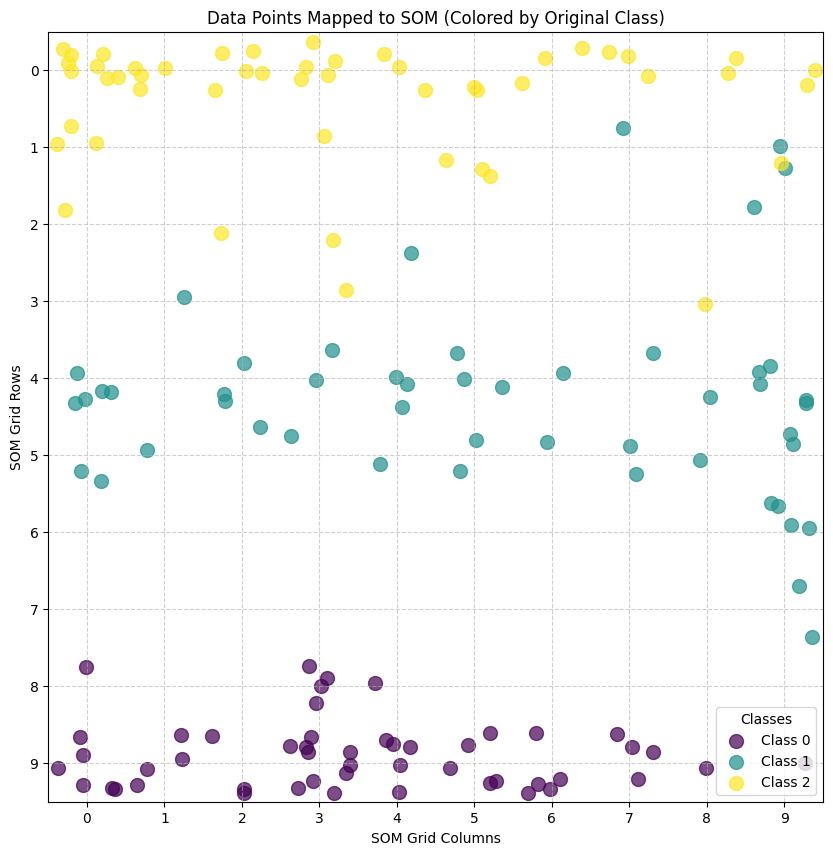

Data point mapping visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Create a scatter plot of the SOM grid with mapped data points colored by class

plt.figure(figsize=(10, 10))

# Create an empty scatter plot for the grid itself or to establish axes
# We can use the grid_rows and grid_cols to define the extent of the plot
plt.scatter([], [], s=0) # Dummy scatter to initialize the plot if no actual grid points are plotted

# Prepare data for plotting
bmu_rows = [item['bmu_row'] for item in bmu_mapping]
bmu_cols = [item['bmu_col'] for item in bmu_mapping]
class_labels = [item['class_label'] for item in bmu_mapping]

# Get unique class labels and map them to colors
unique_classes = np.unique(y)
colors = plt.cm.get_cmap('viridis', len(unique_classes)) # Using viridis colormap

for i, class_label in enumerate(unique_classes):
    # Filter BMU mappings for the current class
    class_bmus = [(r, c) for r, c, l in zip(bmu_rows, bmu_cols, class_labels) if l == class_label]

    if class_bmus:
        # Extract rows and columns for this class
        class_bmu_rows = [bmu[0] for bmu in class_bmus]
        class_bmu_cols = [bmu[1] for bmu in class_bmus]

        # Plot the data points on the SOM grid
        # Add a small random offset for better visibility of overlapping points (jittering)
        plt.scatter(np.array(class_bmu_cols) + np.random.rand(len(class_bmu_cols)) * 0.8 - 0.4,
                    np.array(class_bmu_rows) + np.random.rand(len(class_bmu_rows)) * 0.8 - 0.4,
                    color=colors(i),
                    label=f'Class {class_label}',
                    alpha=0.7,
                    s=100) # Increased size for better visibility

# Add grid lines for better visualization of SOM cells
plt.grid(True, linestyle='--', alpha=0.6)

# Set limits to match the SOM grid dimensions
plt.xlim(-0.5, grid_cols - 0.5)
plt.ylim(-0.5, grid_rows - 0.5)

# Invert y-axis to match common image/matrix representations (optional, but often intuitive for grids)
plt.gca().invert_yaxis()

plt.title('Data Points Mapped to SOM (Colored by Original Class)')
plt.xlabel('SOM Grid Columns')
plt.ylabel('SOM Grid Rows')
plt.legend(title='Classes')
plt.xticks(np.arange(grid_cols))
plt.yticks(np.arange(grid_rows))
plt.show()

print("Data point mapping visualization complete.")

**Reasoning**:
The previous code generated a `MatplotlibDeprecationWarning` because `plt.cm.get_cmap` is deprecated. I will update the code to use the recommended `plt.get_cmap` function instead, which directly supports specifying the number of colors.



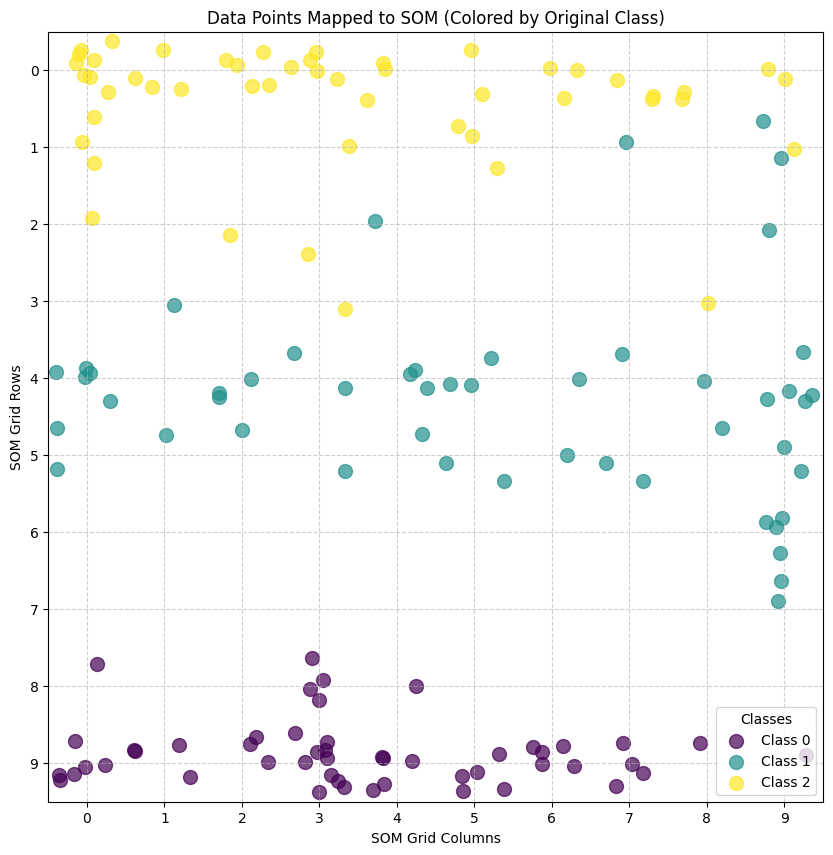

Data point mapping visualization complete.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Create a scatter plot of the SOM grid with mapped data points colored by class

plt.figure(figsize=(10, 10))

# Create an empty scatter plot for the grid itself or to establish axes
# We can use the grid_rows and grid_cols to define the extent of the plot
plt.scatter([], [], s=0) # Dummy scatter to initialize the plot if no actual grid points are plotted

# Prepare data for plotting
bmu_rows = [item['bmu_row'] for item in bmu_mapping]
bmu_cols = [item['bmu_col'] for item in bmu_mapping]
class_labels = [item['class_label'] for item in bmu_mapping]

# Get unique class labels and map them to colors
unique_classes = np.unique(y)
colors = plt.get_cmap('viridis', len(unique_classes)) # Updated to use plt.get_cmap as recommended

for i, class_label in enumerate(unique_classes):
    # Filter BMU mappings for the current class
    class_bmus = [(r, c) for r, c, l in zip(bmu_rows, bmu_cols, class_labels) if l == class_label]

    if class_bmus:
        # Extract rows and columns for this class
        class_bmu_rows = [bmu[0] for bmu in class_bmus]
        class_bmu_cols = [bmu[1] for bmu in class_bmus]

        # Plot the data points on the SOM grid
        # Add a small random offset for better visibility of overlapping points (jittering)
        plt.scatter(np.array(class_bmu_cols) + np.random.rand(len(class_bmu_cols)) * 0.8 - 0.4,
                    np.array(class_bmu_rows) + np.random.rand(len(class_bmu_rows)) * 0.8 - 0.4,
                    color=colors(i),
                    label=f'Class {class_label}',
                    alpha=0.7,
                    s=100) # Increased size for better visibility

# Add grid lines for better visualization of SOM cells
plt.grid(True, linestyle='--', alpha=0.6)

# Set limits to match the SOM grid dimensions
plt.xlim(-0.5, grid_cols - 0.5)
plt.ylim(-0.5, grid_rows - 0.5)

# Invert y-axis to match common image/matrix representations (optional, but often intuitive for grids)
plt.gca().invert_yaxis()

plt.title('Data Points Mapped to SOM (Colored by Original Class)')
plt.xlabel('SOM Grid Columns')
plt.ylabel('SOM Grid Rows')
plt.legend(title='Classes')
plt.xticks(np.arange(grid_cols))
plt.yticks(np.arange(grid_rows))
plt.show()

print("Data point mapping visualization complete.")

## Final Task

### Subtask:
Summarize the findings from the unsupervised learning using the custom-implemented SOM algorithm and the generated visualizations.


## Summary:

### Data Analysis Key Findings

*   **Dataset Preparation**: The Iris dataset, comprising 150 samples with 4 features, was successfully loaded and its features normalized using `MinMaxScaler`, preparing it for unsupervised learning.
*   **SOM Initialization**: A Self-Organizing Map (SOM) with a `10x10` grid (100 neurons) was initialized with random weights, each neuron having a 4-dimensional weight vector corresponding to the input features.
*   **Core SOM Logic Implemented**: Essential SOM training components, including the `find_bmu` function for identifying the Best Matching Unit, a `gaussian_neighborhood` function for calculating neuron influence, and an `exponential decay` function for learning rate and radius, were all successfully implemented and verified.
*   **SOM Training**: The SOM was trained for `100` epochs using the implemented functions. The training process successfully updated the neuron weights, as evidenced by changes from initial random weights.
*   **U-Matrix Visualization**: A U-matrix was calculated and visualized as a heatmap. Regions with higher values in the U-matrix indicate larger distances between neighboring neurons, visually suggesting boundaries between potential clusters formed on the map. For a `10x10` SOM, the U-matrix generated was of shape `(19, 19)`.
*   **Feature Maps Visualization**: Four distinct feature maps were generated and visualized. Each heatmap showed the distribution of a specific feature's weight across the SOM grid, providing insights into which areas of the map are sensitive to particular input characteristics.
*   **Data Point Mapping & Visualization**: All `150` data points from the scaled Iris dataset were mapped to their Best Matching Units (BMUs) on the trained SOM. A scatter plot visualized these mappings, with points colored by their original class labels. The visualization clearly demonstrated that data points belonging to the same class tended to cluster together on the map, indicating the SOM's ability to discover underlying data structures.

### Insights or Next Steps

*   **Insight**: The custom-implemented SOM successfully organized the Iris dataset, creating distinct regions on the map for the different classes (setosa, versicolor, virginica). This demonstrates the SOM's effectiveness in revealing inherent clustering within unsupervised data.
*   **Next Step**: To quantitatively assess the SOM's clustering performance, one could calculate metrics such as purity, adjusted Rand index, or silhouette score using the known class labels to evaluate how well the SOM's clusters align with the true groupings.
